# E02 - The depth wall on MNIST

Bias-free MLPs `784 -> [32]^L -> 10`. Two families differing only in how the rectifier is
written:

| model | init | operator at init |
|---|---|---|
| `relu_mlp` | `xavier` | collapses exponentially with depth |
| `crelu_mlp` | `looks_linear` | exactly orthogonal, every depth, every input |

**Reported metric is test accuracy**, with the learning rate selected on *validation*
accuracy. Selecting on test and then reporting test would make every point the best of
five attempts at the number being reported.

Stage A (baselines only, depths 2..256) locates the wall; Stage B adds ALS at the depths
that matter. Baselines cost ~0.0025 s/step against ALS's ~0.48 s/step at depth 32.

```bash
./scripts_depth_wall.sh
```


In [13]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from olo.viz import load_runs, depth_wall, lr_grid, cost, apply_style

apply_style()
crelu = load_runs("../runs", "e02_crelu_L*")
relu  = load_runs("../runs", "e02_relu_L*")
print(f"crelu/looks-linear: {len(crelu):4d} runs   relu/xavier: {len(relu):4d} runs")
print("depths:", sorted({r.depth for r in crelu}), " methods:", sorted({r.method for r in crelu}))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


crelu/looks-linear:  139 runs   relu/xavier:  120 runs
depths: [2, 4, 8, 16, 32]  methods: ['adam', 'heavyball', 'kfac', 'muon', 'shampoo', 'soap']


## Test accuracy against depth

Each point is that method's best over the whole learning-rate grid at that depth, chosen
on validation. A fall in the curve is a depth effect, not an untuned step size.

Accuracy is bounded in [0, 1], so the y-axis is linear and uncapped; chance is 0.1.

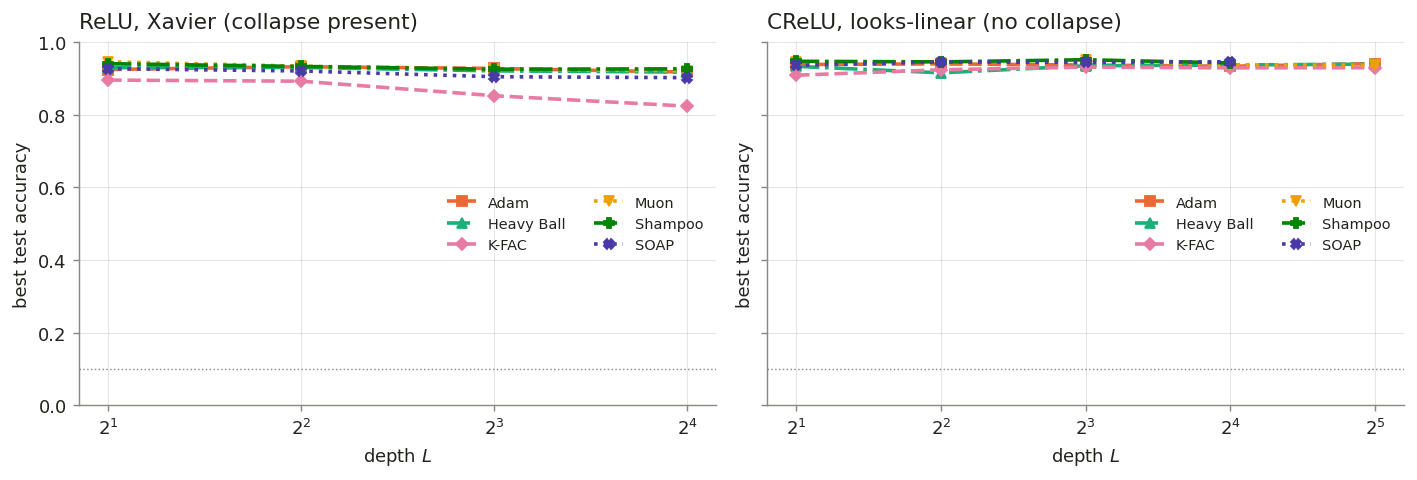

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, runs, name in ((axes[0], relu,  "ReLU, Xavier (collapse present)"),
                       (axes[1], crelu, "CReLU, looks-linear (no collapse)")):
    if runs:
        depth_wall(runs, ax=ax, metric="test_accuracy",
                   select_metric="eval_val_accuracy", title=name)
        ax.axhline(0.1, color="#8a8a85", lw=0.8, ls=":", zorder=0)
        ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig("../figures/e02_depth_wall.pdf")

**What this answers.** If the baselines fall toward chance at some depth while CReLU
holds up, the wall is real and Stage B measures ALS against it. If nothing collapses
through depth 256, the submitted paper's central empirical claim does not survive a real
learning-rate grid -- which is itself the result.

## Is the grid wide enough?

If a method's best sits at an edge of the learning-rate range, its optimum is outside the
grid and its point above is a lower bound, not a tuned result.

relu: 2 cells whose best lr is at a grid edge -> [('kfac', 2), ('adam', 4)]
crelu: 12 cells whose best lr is at a grid edge -> [('kfac', 16), ('muon', 16), ('kfac', 2), ('adam', 32), ('heavyball', 32), ('kfac', 32)]


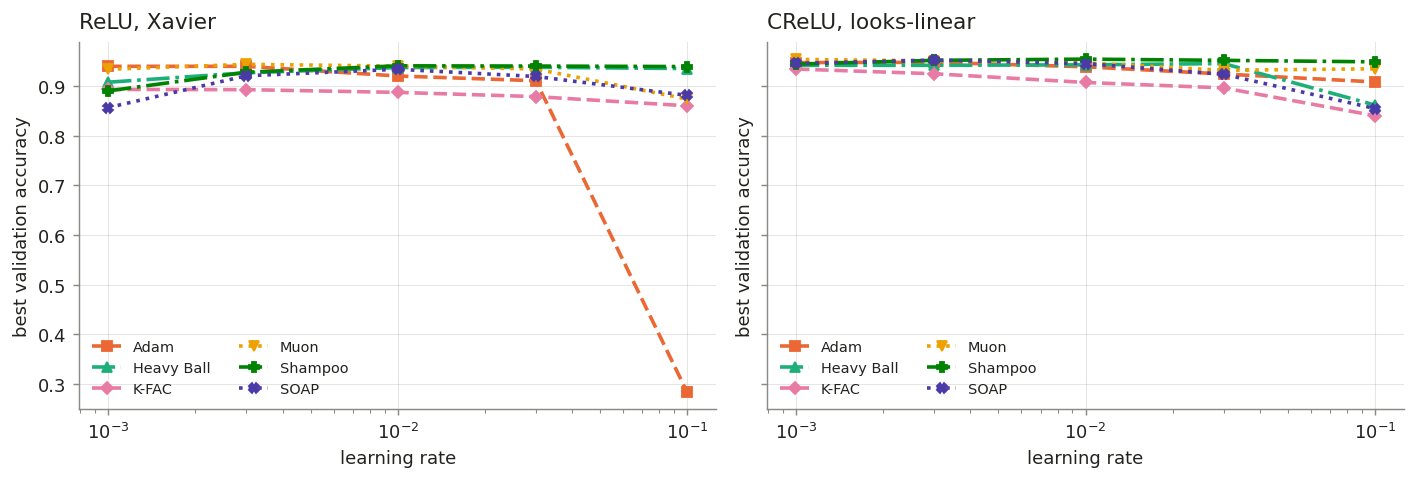

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, runs, name in ((axes[0], relu, "ReLU, Xavier"), (axes[1], crelu, "CReLU, looks-linear")):
    if runs:
        lr_grid(runs, ax=ax, metric="eval_val_accuracy", yscale="linear", title=name)
fig.tight_layout()
fig.savefig("../figures/e02_lr_grid.pdf")

for name, runs in (("relu", relu), ("crelu", crelu)):
    if not runs: continue
    lrs = sorted({r.lr for r in runs})
    from olo.viz import best_per
    edge = [(m, d) for (m, d), r in best_per(runs, "method", "depth",
            metric="eval_val_accuracy", mode="max").items() if r.lr in (lrs[0], lrs[-1])]
    print(f"{name}: {len(edge)} cells whose best lr is at a grid edge" + (f" -> {edge[:6]}" if edge else ""))

## What it costs

The exact solve is orders of magnitude more expensive per step; that belongs in the paper
as a measured number rather than a complexity class.

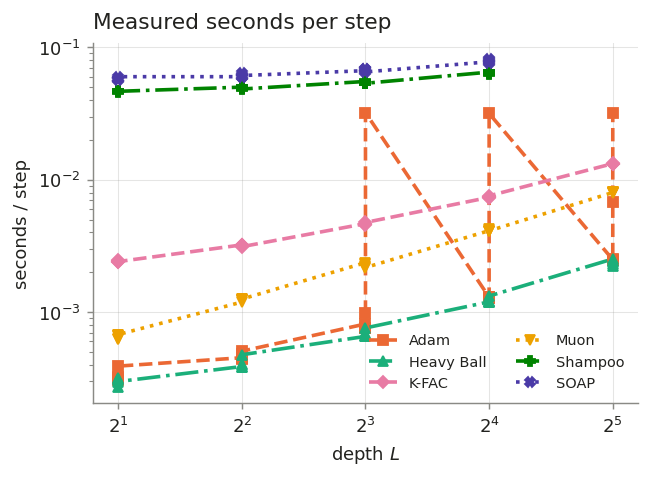

In [16]:
if crelu:
    fig, ax = plt.subplots(figsize=(5.4, 3.6))
    cost(crelu, ax=ax, title="Measured seconds per step")
    fig.savefig("../figures/e02_cost.pdf")